In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print("All libraries loaded successfully")
print("OpenCV version", cv2.__version__)

All libraries loaded successfully
OpenCV version 4.13.0


✅ Camera is working!


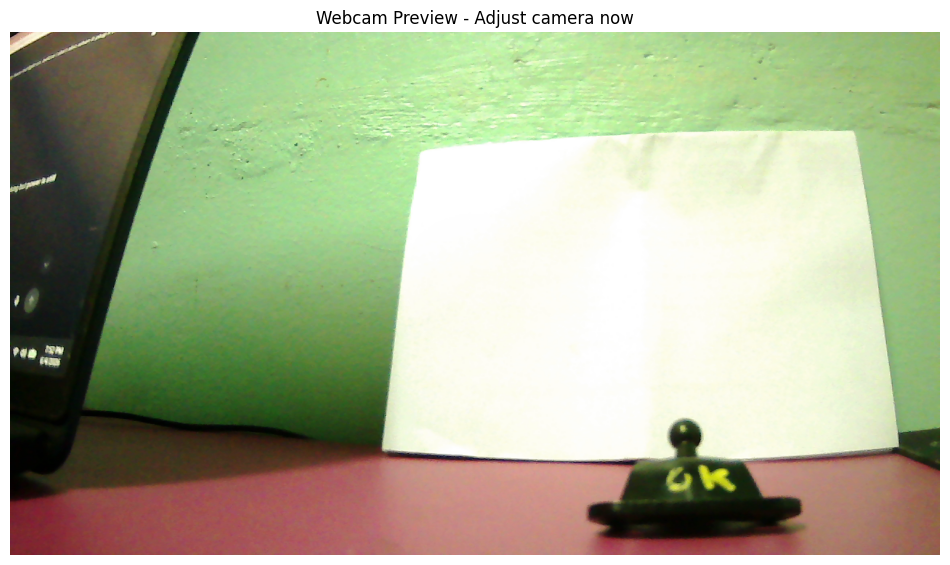

In [3]:
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

ret, frame = cap.read()

if ret:
    print("✅ Camera is working!")
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Webcam Preview - Adjust camera now")
    plt.axis('off')
    plt.show()
else:
    print("❌ Camera not found. Please check USB connection.")

cap.release()

📸 Taking photo in 3 seconds...
✅ Image saved as current_part.jpg


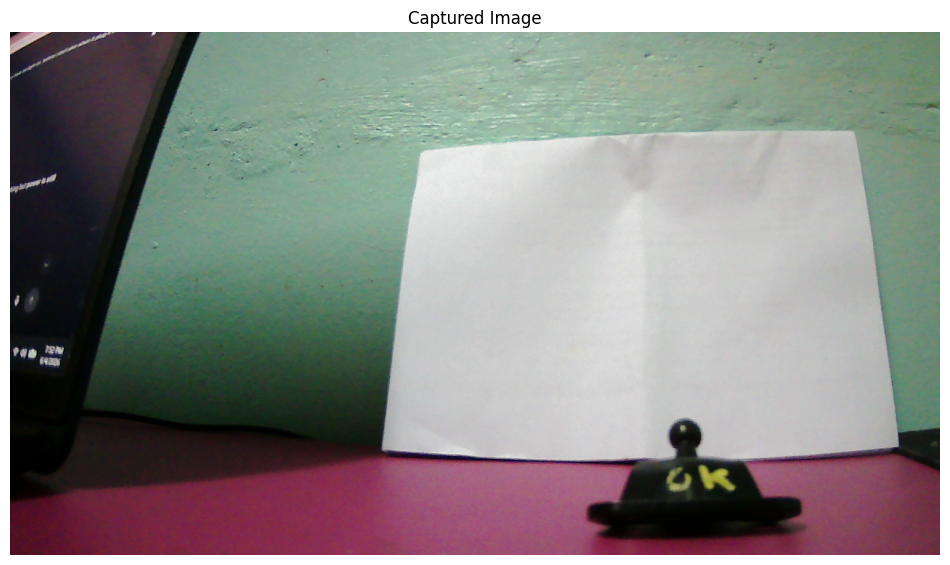

array([[[ 14,  13,  23],
        [ 14,  13,  23],
        [  8,  15,  23],
        ...,
        [102, 131,  92],
        [110, 133,  86],
        [110, 133,  86]],

       [[ 13,  14,  25],
        [ 13,  14,  25],
        [ 13,  17,  19],
        ...,
        [106, 131,  91],
        [108, 134,  84],
        [108, 134,  84]],

       [[  4,  18,  18],
        [  4,  18,  18],
        [  8,  17,  18],
        ...,
        [106, 135,  84],
        [106, 135,  84],
        [107, 136,  86]],

       ...,

       [[ 42,  16,  66],
        [ 43,  17,  67],
        [ 39,  15,  73],
        ...,
        [ 67,  38, 109],
        [ 67,  38, 109],
        [ 68,  40, 110]],

       [[ 27,  20,  67],
        [ 27,  20,  67],
        [ 38,  16,  74],
        ...,
        [ 66,  37, 108],
        [ 69,  36, 105],
        [ 69,  36, 105]],

       [[ 38,  17,  73],
        [ 38,  17,  73],
        [ 40,  14,  78],
        ...,
        [ 67,  37, 112],
        [ 67,  40, 106],
        [ 68,  41, 107]]

In [4]:
def capture_image(filename="current_part.jpg"):
    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    
    print("📸 Taking photo in 3 seconds...")
    for i in range(15):          # Let camera adjust
        ret, frame = cap.read()
    
    if ret:
        cv2.imwrite(filename, frame)
        print(f"✅ Image saved as {filename}")
        
        plt.figure(figsize=(12, 7))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title("Captured Image")
        plt.axis('off')
        plt.show()
    else:
        print("❌ Failed to capture image")
    
    cap.release()
    return frame

# Run capture
capture_image()

/home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


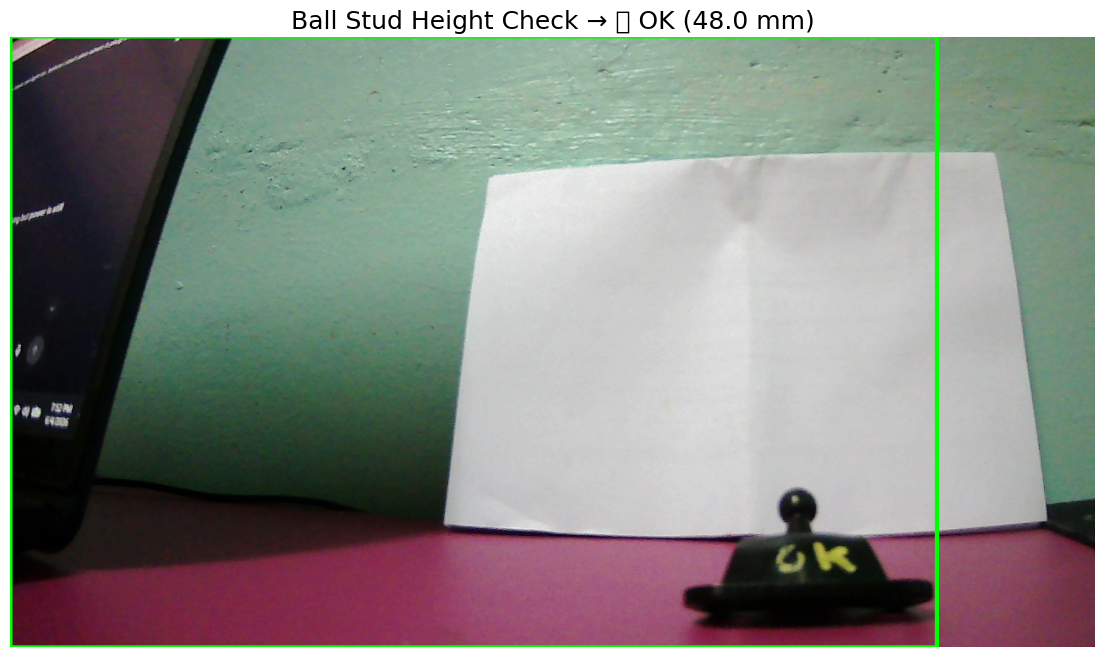

📏 Measured Height: 48.00 mm   →   ✅ OK


In [5]:
def check_ball_stud(filename="current_part.jpg", px_per_mm=15.0, min_ok_mm=26.0):
    img = cv2.imread(filename)
    if img is None:
        print("Image not found!")
        return
    
    # Preprocessing
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thresh = cv2.threshold(blur, 70, 255, cv2.THRESH_BINARY_INV)
    
    # Find the part
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        print("No part detected")
        return
    
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    
    # Calculate real height
    real_height_mm = h / px_per_mm
    status = "✅ OK" if real_height_mm >= min_ok_mm else "❌ NG"
    color = (0, 255, 0) if status == "✅ OK" else (0, 0, 255)
    
    # Draw result
    result = img.copy()
    cv2.rectangle(result, (x, y), (x+w, y+h), color, 4)
    cv2.putText(result, f"Height: {real_height_mm:.1f} mm", (x, y-30),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, color, 3)
    cv2.putText(result, status, (x, y-70), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 4)
    
    plt.figure(figsize=(14, 9))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(f"Ball Stud Height Check → {status} ({real_height_mm:.1f} mm)", fontsize=18)
    plt.axis('off')
    plt.show()
    
    print(f"📏 Measured Height: {real_height_mm:.2f} mm   →   {status}")

# Run the checker
check_ball_stud()

In [2]:
# === LIVE VIDEO PREVIEW (for positioning) ===
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 800)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 600)

print("🎥 Live Video Started - Adjust your camera & part now")
print("Press 'q' key in the video window to stop")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Cannot read camera")
        break
    
    # Optional: Draw guide lines for alignment
    cv2.putText(frame, "Place part on SIDE here", (50, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    # cv2.rectangle(frame, (300, 100), (1000, 600), (0, 255, 255), 3)  # guide box
    
    cv2.imshow("Live Preview - Adjust Position (Press Q to quit)", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("Live preview stopped.")

🎥 Live Video Started - Adjust your camera & part now
Press 'q' key in the video window to stop


qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/plugins"
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bloxwich/ball_stud_checker/myenv/lib/python3.13/site-pack

Live preview stopped.
